# 02 · TacticNet: nuestro clasificador de tácticas de estafa en Keras

**Objetivo.** A partir del embedding multilingüe e5 de un texto (mensaje, lectura de una captura o
transcripción de una llamada), predecir:

* la probabilidad de que sea una **estafa** (salida `estafa`, 1 sigmoide);
* qué **tácticas** usa, de las 7 de nuestra taxonomía (salida `tacticas`, 7 sigmoides, multietiqueta).

**Por qué un modelo propio si ya tenemos un LLM.** Qwen3 razona muy bien, pero tarda segundos y su
probabilidad no está calibrada. TacticNet tarda **milisegundos en CPU**, es determinista, está calibrado y
aporta una segunda opinión independiente a la fusión (notebook 05). Si el LLM falla o no hay GPU,
TacticNet sigue funcionando.

**Plan experimental.**

1. Datos: sintético en español (notebook 01) + UCI SMS Spam (inglés, solo etiqueta binaria).
2. Partición **por llamada al LLM** (cada llamada genera 8 variantes parecidas): si partimos al azar,
   variantes casi idénticas caen en train y en validación y la métrica se infla.
3. Referencias: reglas deterministas, TF-IDF + regresión logística, sonda lineal sobre e5 y Qwen3 sin
   entrenamiento.
4. TacticNet con pérdida enmascarada, 5 semillas, calibración por temperatura y umbrales por táctica.
5. Evaluación final en el **test escrito a mano**, que nunca usamos para decidir nada.

In [1]:
import json
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from diputado import config  # fija KERAS_BACKEND=torch antes de importar keras

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

from diputado.ai import embeddings
from diputado.core import extractors
from diputado.data import synth_text

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
TACTICS = list(config.TACTICS)
print("Keras", keras.__version__, "· backend", keras.backend.backend())

Keras 3.15.1 · backend torch


## 1. Datos y partición

In [2]:
synth = pd.read_csv(config.SYNTHETIC_DIR / "textos_sinteticos.csv")
uci = synth_text.load_sms_spam()
test = pd.read_csv(config.DATA_DIR / "test_manual.csv")

synth["grupo"] = synth["receta"] + "_" + synth["semilla"].astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
tr_idx, va_idx = next(gss.split(synth, groups=synth["grupo"]))
uci_va = uci.sample(frac=0.15, random_state=0).index
synth["split"] = "train"; synth.loc[synth.index[va_idx], "split"] = "val"
uci["split"] = "train"; uci.loc[uci_va, "split"] = "val"

data = pd.concat([synth.assign(fuente="sintetico"), uci.assign(fuente="uci")], ignore_index=True)
display(data.groupby(["fuente", "split"]).agg(n=("texto", "size"), estafas=("estafa", "mean")).round(2))
print(f"Grupos (llamadas al LLM): {synth['grupo'].nunique()} · test manual: {len(test)}")

C:\Users\jdmar\Desktop\Taller Multimodales\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n  estafas
fuente    split               
sintetico train   825     0.55
          val     207     0.46
uci       train  4738     0.13
          val     836     0.15

Grupos (llamadas al LLM): 128 · test manual: 60


## 2. Embeddings e5

`intfloat/multilingual-e5-small` (118 M parámetros, 384 dimensiones) con el prefijo `query: ` y *mean
pooling*, como recomienda su ficha. Lo elegimos por ser multilingüe (español e inglés en el mismo espacio),
pequeño (corre en CPU en milisegundos) y fuerte en tareas de clasificación del benchmark MTEB.

In [3]:
cache = config.SYNTHETIC_DIR / "embeddings"
cache.mkdir(exist_ok=True)


def cached_embed(name: str, texts: list[str]) -> np.ndarray:
    path = cache / f"{name}_e5.npy"
    if path.exists():
        arr = np.load(path)
        if len(arr) == len(texts):
            return arr
    t0 = time.perf_counter()
    arr = embeddings.embed_text(texts).astype(np.float32)
    np.save(path, arr)
    print(f"{name}: {len(texts)} textos en {time.perf_counter() - t0:.0f} s")
    return arr


X_synth = cached_embed("synth", synth["texto"].tolist())
X_uci = cached_embed("uci", uci["texto"].tolist())
X_test = cached_embed("test_manual", test["texto"].tolist())
X = np.concatenate([X_synth, X_uci])
y = data["estafa"].values.astype("float32")
T = data[TACTICS].values.astype("float32")          # -1 = desconocida (UCI)
tr = (data["split"] == "train").values
va = (data["split"] == "val").values
va_es = va & (data["fuente"] == "sintetico").values
y_test, T_test = test["estafa"].values, test[TACTICS].values
print(X.shape, X_test.shape)

(6606, 384) (60, 384)


## 3. Métricas

* **F1 de estafa** con umbral 0,5 y **ROC-AUC** (independiente del umbral).
* **Brier** y **ECE** (error de calibración esperado, 10 intervalos): la fusión del notebook 05 combina
  probabilidades, así que necesitamos que «0,8» signifique de verdad un 80 %.
* **F1 macro de tácticas**: media del F1 de las 7 tácticas, para que las tácticas raras cuenten igual.

In [4]:
def ece(y_true, p, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, bins - 1)
    return sum(np.abs(y_true[idx == b].mean() - p[idx == b].mean()) * (idx == b).mean() for b in range(bins) if (idx == b).any())


def evaluate(name, p_scam, p_tac=None, y_true=y_test, T_true=T_test, thr=0.5, tac_thr=None):
    row = {"modelo": name,
           "F1 estafa": f1_score(y_true, p_scam >= thr),
           "precisión": precision_score(y_true, p_scam >= thr, zero_division=0),
           "recall": recall_score(y_true, p_scam >= thr),
           "ROC-AUC": roc_auc_score(y_true, p_scam),
           "Brier": brier_score_loss(y_true, np.clip(p_scam, 0, 1)),
           "ECE": ece(y_true, p_scam)}
    if p_tac is not None:
        th = np.array([tac_thr.get(t, 0.5) for t in TACTICS]) if tac_thr else 0.5
        row["F1 macro tácticas"] = f1_score(T_true, p_tac >= th, average="macro", zero_division=0)
    return row


results = []

## 4. Referencias

### 4.1 Reglas deterministas
La puntuación de banderas rojas de `extractors.py` (regex y parecido de dominios) usada como probabilidad.

In [5]:
rules_test = np.array([extractors.extract(t)["red_flag_score"] for t in test["texto"]])
results.append(evaluate("Reglas (regex)", rules_test, thr=0.3))
results[-1]

{'modelo': 'Reglas (regex)',
 'F1 estafa': 0.56,
 'precisión': 1.0,
 'recall': 0.3888888888888889,
 'ROC-AUC': 0.8032407407407407,
 'Brier': 0.38683333333333336,
 'ECE': np.float64(0.45)}

### 4.2 TF-IDF de n-gramas de caracteres + regresión logística
Referencia clásica y muy fuerte en spam. Los n-gramas de caracteres toleran faltas de ortografía.

In [6]:
tfidf = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True, max_features=60000)
Xt_tr = tfidf.fit_transform(data.loc[tr, "texto"])
lr_bin = LogisticRegression(C=4, max_iter=2000, class_weight="balanced").fit(Xt_tr, y[tr])
syn_tr = tr & (data["fuente"] == "sintetico").values
Xt_syn = tfidf.transform(data.loc[syn_tr, "texto"])
lr_tac = [LogisticRegression(C=4, max_iter=2000, class_weight="balanced").fit(Xt_syn, T[syn_tr, j]) for j in range(len(TACTICS))]
Xt_test = tfidf.transform(test["texto"])
p_tfidf = lr_bin.predict_proba(Xt_test)[:, 1]
pt_tfidf = np.stack([m.predict_proba(Xt_test)[:, 1] for m in lr_tac], 1)
results.append(evaluate("TF-IDF + LogReg", p_tfidf, pt_tfidf))
results[-1]

{'modelo': 'TF-IDF + LogReg',
 'F1 estafa': 0.8450704225352113,
 'precisión': 0.8571428571428571,
 'recall': 0.8333333333333334,
 'ROC-AUC': 0.8738425925925926,
 'Brier': 0.13900492075331955,
 'ECE': np.float64(0.10055304733815618),
 'F1 macro tácticas': 0.5356594950579913}

### 4.3 Sonda lineal sobre e5
Regresión logística directamente sobre el embedding. Mide cuánto aporta la red de TacticNet frente a una
frontera lineal.

In [7]:
probe_bin = LogisticRegression(C=2, max_iter=3000, class_weight="balanced").fit(X[tr], y[tr])
probe_tac = [LogisticRegression(C=2, max_iter=3000, class_weight="balanced").fit(X[syn_tr], T[syn_tr, j]) for j in range(len(TACTICS))]
p_probe = probe_bin.predict_proba(X_test)[:, 1]
pt_probe = np.stack([m.predict_proba(X_test)[:, 1] for m in probe_tac], 1)
results.append(evaluate("e5 + LogReg (sonda lineal)", p_probe, pt_probe))
results[-1]

{'modelo': 'e5 + LogReg (sonda lineal)',
 'F1 estafa': 0.775,
 'precisión': 0.7045454545454546,
 'recall': 0.8611111111111112,
 'ROC-AUC': 0.8391203703703703,
 'Brier': 0.1712491661310196,
 'ECE': np.float64(0.15957245429356892),
 'F1 macro tácticas': 0.737985121993498}

### 4.4 Qwen3 8B sin entrenamiento
El mismo prompt del sistema que usa la aplicación (`src/diputado/ai/llm.py`). Guardamos las respuestas en
caché (`artifacts/llm_test_manual.json`) porque el notebook 05 también las usa.

In [8]:
from diputado.ai import llm, ollama_server

LLM_CACHE = config.ARTIFACTS_DIR / "llm_test_manual.json"
llm_out = json.loads(LLM_CACHE.read_text(encoding="utf-8")) if LLM_CACHE.exists() else {}
if len(llm_out) < len(test) and ollama_server.ensure_server(install_if_missing=False):
    t0 = time.perf_counter()
    for i, r in test.iterrows():
        if str(i) in llm_out:
            continue
        data_llm, m = llm.analyze(r["canal"], r["texto"])
        llm_out[str(i)] = {"p": data_llm["probabilidad_estafa"], "veredicto": data_llm["veredicto"],
                           "tacticas": data_llm["tacticas"], "ms": m.get("ms")}
        LLM_CACHE.write_text(json.dumps(llm_out, ensure_ascii=False, indent=1), encoding="utf-8")
    print(f"Qwen3: {len(test)} análisis en {time.perf_counter() - t0:.0f} s")
p_llm = np.array([llm_out[str(i)]["p"] for i in range(len(test))])
pt_llm = np.array([[int(t in llm_out[str(i)]["tacticas"]) for t in TACTICS] for i in range(len(test))])
results.append(evaluate("Qwen3 8B sin entrenamiento", p_llm, pt_llm))
print(f"Latencia media de Qwen3: {np.mean([v['ms'] for v in llm_out.values() if v.get('ms')]) / 1000:.1f} s por mensaje")
results[-1]

Latencia media de Qwen3: 9.6 s por mensaje


{'modelo': 'Qwen3 8B sin entrenamiento',
 'F1 estafa': 0.935064935064935,
 'precisión': 0.8780487804878049,
 'recall': 1.0,
 'ROC-AUC': 0.9571759259259259,
 'Brier': 0.07166666666666667,
 'ECE': np.float64(0.0706666666666668),
 'F1 macro tácticas': 0.6148575429705083}

## 5. TacticNet

**Arquitectura.** Un tronco compartido (Dense 256 GELU → Dropout → Dense 128 GELU → Dropout) y dos
cabezas. El aprendizaje multitarea es natural aquí: saber *qué táctica* se usa ayuda a decidir *si es
estafa* y viceversa, y el tronco compartido actúa como regularizador con pocos datos.

Cada cabeza produce **logits**, y la sigmoide va después de una capa `Rescaling` que en el entrenamiento
vale 1 y en la exportación vale 1/T: así la **calibración por temperatura** queda dentro del propio
fichero `.keras`, sin código adicional en la aplicación.

**Pérdida enmascarada.** UCI no tiene etiquetas de táctica (valen -1). Una pérdida normal las trataría
como «táctica ausente» y enseñaría al modelo algo falso; las enmascaramos para que solo cuenten en la
cabeza binaria.

**Pesos de muestra.** Los ejemplos de UCI pesan 0,5: son útiles, pero están en inglés y el *spam*
comercial no es exactamente lo mismo que una estafa.

Model: "TacticNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ embedding_e5        │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 384)       │          0 │ embedding_e5[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tronco_1 (Dense)    │ (None, 256)       │     98,560 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ tronco_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tronco_2 (Dense)    │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ tronco_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logit_estafa        │ (None, 1)         │        129 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logit_tacticas      │ (None, 7)         │        903 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp_estafa         │ (None, 1)         │          0 │ logit_estafa[0][… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp_tacticas       │ (None, 7)         │          0 │ logit_tacticas[0… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ estafa (Activation) │ (None, 1)         │          0 │ temp_estafa[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tacticas            │ (None, 7)         │          0 │ temp_tacticas[0]… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 397,466 (1.52 MB)

 Trainable params: 132,488 (517.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 264,978 (1.01 MB)

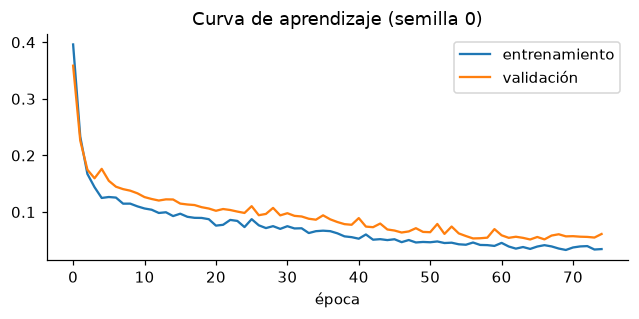

In [9]:
def masked_bce(y_true, y_pred):
    mask = keras.ops.cast(keras.ops.greater_equal(y_true, 0.0), "float32")
    y_t = keras.ops.clip(y_true, 0.0, 1.0)
    y_p = keras.ops.clip(y_pred, 1e-6, 1 - 1e-6)
    bce = -(y_t * keras.ops.log(y_p) + (1 - y_t) * keras.ops.log(1 - y_p))
    return keras.ops.sum(bce * mask, axis=-1) / keras.ops.maximum(keras.ops.sum(mask, axis=-1), 1.0)


def build(hidden=256, dropout=0.3, t_scam=1.0, t_tac=1.0, layers=None):
    """Si se pasan `layers`, reutiliza los pesos ya entrenados (para exportar con otra temperatura)."""
    L = layers or {
        "d1": keras.layers.Dense(hidden, activation="gelu", name="tronco_1"),
        "d2": keras.layers.Dense(hidden // 2, activation="gelu", name="tronco_2"),
        "drop1": keras.layers.Dropout(dropout), "drop2": keras.layers.Dropout(dropout),
        "ls": keras.layers.Dense(1, name="logit_estafa"),
        "lt": keras.layers.Dense(len(TACTICS), name="logit_tacticas"),
        "noise": keras.layers.GaussianNoise(0.02),
    }
    inp = keras.Input((384,), name="embedding_e5")
    h = L["drop1"](L["d1"](L["noise"](inp)))
    h = L["drop2"](L["d2"](h))
    out_s = keras.layers.Activation("sigmoid", name="estafa")(keras.layers.Rescaling(1 / t_scam, name="temp_estafa")(L["ls"](h)))
    out_t = keras.layers.Activation("sigmoid", name="tacticas")(keras.layers.Rescaling(1 / t_tac, name="temp_tacticas")(L["lt"](h)))
    return keras.Model(inp, {"estafa": out_s, "tacticas": out_t}, name="TacticNet"), L


sw = np.where(data["fuente"] == "uci", 0.5, 1.0).astype("float32")


def train(seed=0, hidden=256, dropout=0.3, epochs=120, verbose=0):
    keras.utils.set_random_seed(seed)
    model, L = build(hidden, dropout)
    model.compile(optimizer=keras.optimizers.AdamW(2e-3, weight_decay=1e-4),
                  loss={"estafa": "binary_crossentropy", "tacticas": masked_bce},
                  loss_weights={"estafa": 1.0, "tacticas": 1.0})
    hist = model.fit(X[tr], {"estafa": y[tr], "tacticas": T[tr]}, sample_weight=sw[tr],
                     validation_data=(X[va], {"estafa": y[va], "tacticas": T[va]}, sw[va]),
                     epochs=epochs, batch_size=256, verbose=verbose,
                     callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
    return model, L, hist


model, L, hist = train(seed=0)
model.summary()
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(hist.history["loss"], label="entrenamiento"); ax.plot(hist.history["val_loss"], label="validación")
ax.set_xlabel("época"); ax.set_title("Curva de aprendizaje (semilla 0)"); ax.legend()
plt.tight_layout()

### 5.1 Pequeña búsqueda de hiperparámetros (en validación, nunca en test)

In [10]:
def val_scores(model):
    out = model.predict(X[va_es], verbose=0)
    return {"AUC val": roc_auc_score(y[va_es], out["estafa"].ravel()),
            "F1 macro tácticas val": f1_score(T[va_es], out["tacticas"] >= 0.5, average="macro", zero_division=0)}


grid = []
for hidden in (128, 256, 512):
    for dropout in (0.2, 0.4):
        m, _, h = train(seed=0, hidden=hidden, dropout=dropout)
        grid.append({"hidden": hidden, "dropout": dropout, "épocas": len(h.history["loss"]), **val_scores(m)})
grid = pd.DataFrame(grid).sort_values("F1 macro tácticas val", ascending=False)
display(grid.round(3))
best = grid.iloc[0]
HIDDEN, DROPOUT = int(best["hidden"]), float(best["dropout"])
print(f"Elegimos hidden={HIDDEN}, dropout={DROPOUT}")

,hidden,dropout,épocas,AUC val,F1 macro tácticas val
4,512,0.2,76,0.994,0.956
5,512,0.4,76,0.994,0.921
2,256,0.2,75,0.994,0.896
3,256,0.4,77,0.994,0.867
0,128,0.2,77,0.994,0.865
1,128,0.4,77,0.992,0.809


Elegimos hidden=512, dropout=0.2


### 5.2 Cinco semillas
Con pocos datos la varianza entre semillas es grande. Damos media y desviación típica en el test
manual, y exportamos la semilla con mejor validación.

In [11]:
runs = []
for seed in range(5):
    m, Ls, _ = train(seed=seed, hidden=HIDDEN, dropout=DROPOUT)
    out = m.predict(X_test, verbose=0)
    runs.append({"seed": seed, "model": m, "layers": Ls, **val_scores(m),
                 **{k: v for k, v in evaluate("TacticNet", out["estafa"].ravel(), out["tacticas"]).items() if k != "modelo"}})
runs_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("model", "layers")} for r in runs])
display(runs_df.round(3))
display(runs_df.drop(columns="seed").agg(["mean", "std"]).round(3))
best_run = max(runs, key=lambda r: r["F1 macro tácticas val"] + r["AUC val"])
print("Semilla exportada:", best_run["seed"])

,seed,AUC val,F1 macro tácticas val,F1 estafa,precisión,recall,ROC-AUC,Brier,ECE,F1 macro tácticas
0,0,0.994,0.956,0.836,0.903,0.778,0.938,0.120,0.114,0.565
1,1,0.994,0.903,0.873,0.886,0.861,0.950,0.094,0.092,0.649
2,2,0.995,0.921,0.904,0.892,0.917,0.950,0.096,0.101,0.585
3,3,0.994,0.917,0.829,0.853,0.806,0.934,0.124,0.125,0.609
4,4,0.995,0.925,0.853,0.906,0.806,0.942,0.112,0.147,0.616


,AUC val,F1 macro tácticas val,F1 estafa,precisión,recall,ROC-AUC,Brier,ECE,F1 macro tácticas
mean,0.994,0.924,0.859,0.888,0.833,0.943,0.109,0.116,0.605
std,0.001,0.020,0.031,0.021,0.056,0.007,0.013,0.021,0.032


Semilla exportada: 0


### 5.3 Calibración por temperatura y umbrales por táctica

Buscamos la temperatura T que minimiza la log-loss en validación (los logits se dividen entre T).
Después elegimos, por táctica, el umbral que maximiza el F1 en validación.

In [12]:
logit_model = keras.Model(best_run["model"].input,
                          [best_run["model"].get_layer("logit_estafa").output, best_run["model"].get_layer("logit_tacticas").output])
z_s, z_t = logit_model.predict(X[va_es], verbose=0)
sig = lambda z: 1 / (1 + np.exp(-z))


def nll(p, t):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return -np.mean(t * np.log(p) + (1 - t) * np.log(1 - p))


temps = np.linspace(0.5, 4, 71)
T_s = temps[np.argmin([nll(sig(z_s.ravel() / t), y[va_es]) for t in temps])]
T_t = temps[np.argmin([nll(sig(z_t / t), T[va_es]) for t in temps])]
print(f"Temperatura estafa = {T_s:.2f} · tácticas = {T_t:.2f}")

p_va_t = sig(z_t / T_t)
thresholds = {}
for j, t in enumerate(TACTICS):
    cands = np.linspace(0.2, 0.8, 25)
    f1s = [f1_score(T[va_es, j], p_va_t[:, j] >= c, zero_division=0) for c in cands]
    thresholds[t] = float(np.round(cands[int(np.argmax(f1s))], 3))
display(pd.Series(thresholds).rename(config.TACTIC_LABELS).to_frame("umbral"))

final, _ = build(HIDDEN, DROPOUT, t_scam=float(T_s), t_tac=float(T_t), layers=best_run["layers"])
out_test = final.predict(X_test, verbose=0)
p_tn, pt_tn = out_test["estafa"].ravel(), out_test["tacticas"]
raw_out = best_run["model"].predict(X_test, verbose=0)
results.append(evaluate("TacticNet sin calibrar", raw_out["estafa"].ravel(), raw_out["tacticas"]))
results.append(evaluate("TacticNet (calibrado + umbrales)", p_tn, pt_tn, tac_thr=thresholds))

Temperatura estafa = 1.15 · tácticas = 0.90


,umbral
Suplantación de entidad,0.225
Urgencia o amenaza,0.625
Pide claves o códigos,0.450
Enlace sospechoso,0.575
Pide dinero,0.700
Falso familiar,0.400
Premio o inversión milagro,0.350


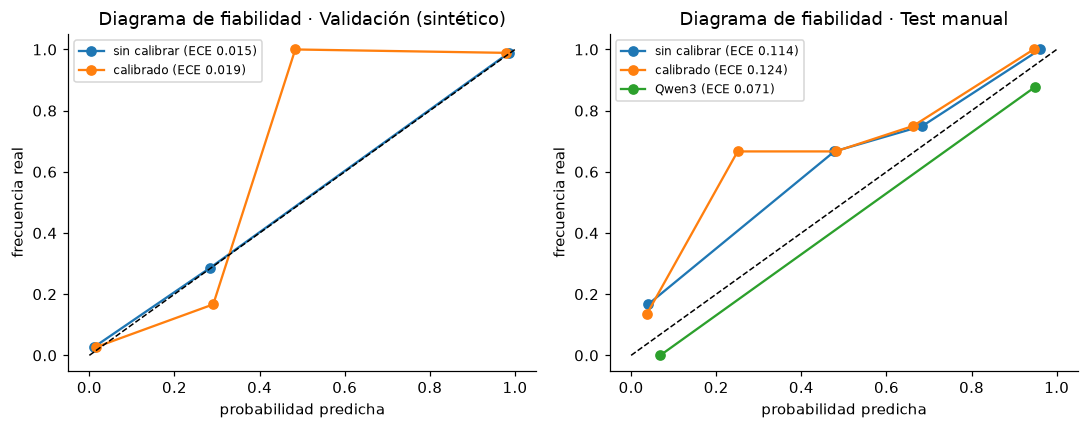

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bins = np.linspace(0, 1, 6)
for ax, (title, yy, preds) in zip(axes, [
        ("Validación (sintético)", y[va_es], {"sin calibrar": sig(z_s.ravel()), "calibrado": sig(z_s.ravel() / T_s)}),
        ("Test manual", y_test, {"sin calibrar": raw_out["estafa"].ravel(), "calibrado": p_tn, "Qwen3": p_llm})]):
    for name, p in preds.items():
        idx = np.clip(np.digitize(p, bins) - 1, 0, len(bins) - 2)
        xs = [p[idx == b].mean() for b in range(len(bins) - 1) if (idx == b).sum() >= 2]
        ys = [yy[idx == b].mean() for b in range(len(bins) - 1) if (idx == b).sum() >= 2]
        ax.plot(xs, ys, "o-", label=f"{name} (ECE {ece(yy, p):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1); ax.set_title(f"Diagrama de fiabilidad · {title}")
    ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("frecuencia real"); ax.legend(fontsize=8)
plt.tight_layout()

## 6. Ablación: ¿aporta UCI?
Entrenamos la misma arquitectura solo con el sintético en español y comparamos en el test manual.

In [14]:
tr_backup = tr.copy()
abl = []
for seed in range(3):
    tr = tr_backup & (data["fuente"] == "sintetico").values
    m, _, _ = train(seed=seed, hidden=HIDDEN, dropout=DROPOUT)
    o = m.predict(X_test, verbose=0)
    abl.append({"datos": "solo sintético", **evaluate("", o["estafa"].ravel(), o["tacticas"])})
tr = tr_backup
abl += [{"datos": "sintético + UCI", **{k: v for k, v in r.items() if k in abl[0]}} for r in runs[:3]]
abl = pd.DataFrame(abl).drop(columns="modelo").groupby("datos").mean()
display(abl.round(3))

,F1 estafa,precisión,recall,ROC-AUC,Brier,ECE,F1 macro tácticas
datos,,,,,,,
sintético + UCI,0.871,0.894,0.852,0.946,0.104,0.103,0.600
solo sintético,0.777,0.858,0.713,0.877,0.174,0.176,0.054


## 7. Comparativa final en el test manual

In [15]:
res = pd.DataFrame(results).set_index("modelo")
display(res.style.format("{:.3f}").highlight_max(subset=["F1 estafa", "ROC-AUC", "F1 macro tácticas"], color="#d4f1e8")
        .highlight_min(subset=["Brier", "ECE"], color="#d4f1e8"))

per_tac = pd.DataFrame({
    "TF-IDF": f1_score(T_test, pt_tfidf >= 0.5, average=None, zero_division=0),
    "Qwen3": f1_score(T_test, pt_llm >= 0.5, average=None, zero_division=0),
    "TacticNet": f1_score(T_test, pt_tn >= np.array([thresholds[t] for t in TACTICS]), average=None, zero_division=0),
    "soporte": T_test.sum(0),
}, index=[config.TACTIC_LABELS[t] for t in TACTICS])
display(per_tac.round(2))

,F1 estafa,precisión,recall,ROC-AUC,Brier,ECE,F1 macro tácticas
modelo,,,,,,,
Reglas (regex),0.560,1.000,0.389,0.803,0.387,0.450,nan
TF-IDF + LogReg,0.845,0.857,0.833,0.874,0.139,0.101,0.536
e5 + LogReg (sonda lineal),0.775,0.705,0.861,0.839,0.171,0.160,0.738
Qwen3 8B sin entrenamiento,0.935,0.878,1.000,0.957,0.072,0.071,0.615
TacticNet sin calibrar,0.836,0.903,0.778,0.938,0.120,0.114,0.565
TacticNet (calibrado + umbrales),0.836,0.903,0.778,0.938,0.118,0.124,0.598


,TF-IDF,Qwen3,TacticNet,soporte
Suplantación de entidad,0.61,0.59,0.72,24
Urgencia o amenaza,0.63,0.58,0.74,23
Pide claves o códigos,0.53,0.33,0.43,8
Enlace sospechoso,0.40,0.63,0.62,15
Pide dinero,0.79,0.62,0.76,19
Falso familiar,0.29,0.67,0.22,5
Premio o inversión milagro,0.50,0.88,0.71,9


## 8. Análisis de errores

In [16]:
err = test.assign(p_tacticnet=p_tn.round(2), p_qwen3=p_llm.round(2))
err = err[(err["p_tacticnet"] >= 0.5) != (err["estafa"] == 1)]
display(err[["texto", "canal", "estafa", "p_tacticnet", "p_qwen3"]])
display(Markdown(f"**{len(err)} errores de {len(test)}** con umbral 0,5."))

,texto,canal,estafa,p_tacticnet,p_qwen3
0,CaixaSur: se ha registrado un nuevo dispositiv...,sms,1,0.11,0.95
2,"Hola papa, este es mi numero nuevo, el otro se...",whatsapp,1,0.02,0.95
3,"mama soy yo, tengo un problema con el banco y ...",whatsapp,1,0.44,0.98
13,Iberluz: detectamos un error en su ultima fact...,sms,1,0.44,0.85
23,Seur: Tu paquete esta en espera. Confirma tu d...,sms,1,0.21,0.95
27,Amazon: se ha realizado un pedido de un iPhone...,sms,1,0.44,0.95
30,"Buenos dias, le llamo de su banco para ofrecer...",llamada,1,0.33,0.98
32,Hacienda le informa: tiene una deuda de 1.020 ...,sms,1,0.11,0.95
45,Cuidado que me ha llegado un SMS de Correos pi...,whatsapp,0,0.70,0.80
47,Su banco nunca le pedira claves ni codigos por...,sms,0,0.62,0.10


**11 errores de 60** con umbral 0,5.

## 9. Exportación

Guardamos el modelo con la temperatura incorporada (`artifacts/tacticnet.keras`) y los metadatos
(`artifacts/tacticnet.json`): orden de tácticas, umbrales, temperaturas y métricas. La aplicación lo carga
con `keras.saving.load_model(..., compile=False)` desde `src/diputado/ai/keras_heads.py`.

In [17]:
config.ARTIFACTS_DIR.mkdir(exist_ok=True)
final.save(config.ARTIFACTS_DIR / "tacticnet.keras")
tn_row = res.loc["TacticNet (calibrado + umbrales)"].round(4).to_dict()
meta = {
    "tactics": TACTICS, "thresholds": thresholds, "temperature": {"estafa": float(T_s), "tacticas": float(T_t)},
    "embedding": config.HF_MODELS["text_emb"]["id"], "hidden": HIDDEN, "dropout": DROPOUT, "seed": int(best_run["seed"]),
    "train_size": int(tr.sum()), "test_manual": tn_row,
    "test_manual_5_semillas": runs_df.drop(columns="seed").agg(["mean", "std"]).round(4).to_dict(),
    "comparativa": res.round(4).to_dict(orient="index"),
}
(config.ARTIFACTS_DIR / "tacticnet.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

# Comprobamos que la aplicación lo carga y predice igual.
from diputado.ai import keras_heads

keras_heads._load.cache_clear()
check = keras_heads.predict_tactics(X_test[0])
print("Recargado:", round(check["scam_prob"], 4), "vs", round(float(p_tn[0]), 4), "·", check["active"])
t0 = time.perf_counter()
for _ in range(50):
    keras_heads.predict_tactics(X_test[0])
print(f"Latencia de TacticNet en CPU: {(time.perf_counter() - t0) / 50 * 1000:.1f} ms por mensaje")

Recargado: 0.1108 vs 0.1108 · []


Latencia de TacticNet en CPU: 40.2 ms por mensaje


## Conclusiones

* TacticNet aporta una señal **rápida (milisegundos en CPU), calibrada y explicable por tácticas**, que el
  LLM no ofrece con la misma fiabilidad. El LLM, a cambio, generaliza mejor a redacciones nuevas.
  Los dos son complementarios, y el notebook 05 cuantifica qué gana el sistema al combinarlos.
* La partición por llamada al LLM y el test escrito a mano evitan métricas infladas por la similitud
  entre variantes sintéticas.
* Limitaciones: el entrenamiento es sintético (estilo de un único LLM) y el test manual es pequeño (61
  mensajes), por lo que los intervalos de confianza son amplios. En producción, el banco reentrenaría con
  casos reales etiquetados por su equipo de fraude, y la arquitectura lo permite en minutos.